In [1]:
!pip install torch-geometric imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00


              NEUROVISTA DATASET SPLIT REPORT               
Class Name      | Total      | Train (80%)  | Test (20%)  
------------------------------------------------------------
AD              | 70         | 56           | 14          
LMCI            | 70         | 56           | 14          
EMCI            | 70         | 56           | 14          
CN              | 70         | 56           | 14          
------------------------------------------------------------
Fold 1 Optimized.
Fold 2 Optimized.
Fold 3 Optimized.
Fold 4 Optimized.
Fold 5 Optimized.

             NEUROVISTA FINAL DIAGNOSTIC REPORT             
OVERALL SYSTEM ACCURACY: 72.14%
------------------------------------------------------------
              precision    recall  f1-score   support

          AD       0.84      0.66      0.74        70
        LMCI       0.71      0.84      0.77        70
        EMCI       0.87      0.79      0.83        70
          CN       0.53      0.60      0.56        70

    a

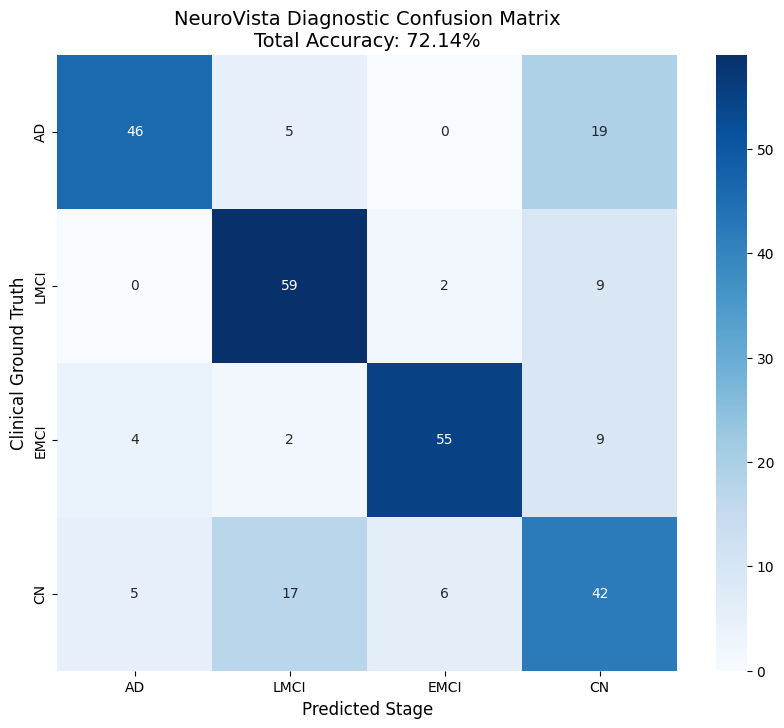

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import GATv2Conv, AttentionalAggregation, BatchNorm, GraphSizeNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_DIM = 32
TARGET_SAMPLES = 70
CLASS_NAMES = ['AD', 'LMCI', 'EMCI', 'CN']

# --- 2. BATCHING ENGINE ---
class MultiModalBatch:
    def __init__(self, data_list):
        self.x = torch.cat([d.x for d in data_list], dim=0)
        self.y = torch.cat([d.y for d in data_list], dim=0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], dim=0)
        self.batch = torch.cat([torch.full((d.num_nodes,), i, dtype=torch.long) for i, d in enumerate(data_list)], dim=0)
        curr_n = 0
        e_p, e_g, e_w = [], [], []
        for d in data_list:
            e_p.append(d.edge_index + curr_n)
            e_g.append(d.edge_granger + curr_n)
            e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes
        self.edge_index = torch.cat(e_p, dim=1)
        self.edge_granger = torch.cat(e_g, dim=1)
        self.edge_wavelet = torch.cat(e_w, dim=1)

    def to(self, device):
        self.x, self.y, self.batch = self.x.to(device), self.y.to(device), self.batch.to(device)
        self.edge_index = self.edge_index.to(device)
        self.edge_granger = self.edge_granger.to(device)
        self.edge_wavelet = self.edge_wavelet.to(device)
        self.extra_feat = self.extra_feat.to(device)
        return self

# --- 3. ARCHITECTURE ---
class NeuroVistaPrecisionNet(torch.nn.Module):
    def __init__(self, node_in, vector_in):
        super().__init__()
        self.gat_p = GATv2Conv(node_in, 64, heads=8, concat=True, dropout=0.2)
        self.gat_g = GATv2Conv(node_in, 64, heads=8, concat=True, dropout=0.2)
        self.gat_w = GATv2Conv(node_in, 64, heads=8, concat=True, dropout=0.2)
        self.gnorm = GraphSizeNorm()
        self.bn = BatchNorm(512)
        self.pool = AttentionalAggregation(nn.Sequential(nn.Linear(512, 1)))
        self.classifier = nn.Sequential(
            nn.Linear(512*3 + vector_in, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, data):
        p = F.elu(self.bn(self.gnorm(self.gat_p(data.x, data.edge_index), data.batch)))
        g = F.elu(self.bn(self.gnorm(self.gat_g(data.x, data.edge_granger), data.batch)))
        w = F.elu(self.bn(self.gnorm(self.gat_w(data.x, data.edge_wavelet), data.batch)))
        pooled = torch.cat([self.pool(p, data.batch), self.pool(g, data.batch), self.pool(w, data.batch), data.extra_feat], dim=1)
        return self.classifier(pooled)

# --- 4. DATA PIPELINE ---
def load_dataset(base_path):
    X_raw, y_raw = [], []
    class_map = {'AD_graphs': 0, 'LMCI_graphs': 1, 'EMCI_graphs': 2, 'CN_graphs': 3}
    for folder, val in class_map.items():
        p_path = f"{base_path}/{folder}/Graph_Output"
        if not os.path.exists(p_path): continue
        for f in os.listdir(p_path):
            sid = f.replace('_corr_matrix.npy', '')
            try:
                p = np.load(f"{p_path}/{f}")
                g = np.load(f"{base_path}/{folder}/Graph_Output_Granger/{sid}_granger_matrix.npy")
                w = np.load(f"{base_path}/{folder}/Graph_Output_Coherence/{sid}_coherence_matrix.npy")
                X_raw.append(np.hstack([p.flatten(), g.flatten(), w.flatten()]))
                y_raw.append(val)
            except: continue
    X_raw, y_raw = np.array(X_raw), np.array(y_raw)
    sm = SMOTE(sampling_strategy={i: TARGET_SAMPLES for i in range(4)}, random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X_raw, y_raw)
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_res)
    size, ds = NUM_NODES * NUM_NODES, []
    for i in range(len(y_res)):
        p_mat = X_res[i, :size].reshape(NUM_NODES, NUM_NODES)
        g_mat = X_res[i, size:2*size].reshape(NUM_NODES, NUM_NODES)
        w_mat = X_res[i, 2*size:].reshape(NUM_NODES, NUM_NODES)
        t = np.percentile(np.abs(p_mat), 85)
        ds.append(Data(x=torch.tensor(p_mat[:, :PCA_DIM], dtype=torch.float),
                       edge_index=torch.tensor(np.argwhere(np.abs(p_mat) > t).T, dtype=torch.long),
                       edge_granger=torch.tensor(np.argwhere(np.abs(g_mat) > t).T, dtype=torch.long),
                       edge_wavelet=torch.tensor(np.argwhere(np.abs(w_mat) > t).T, dtype=torch.long),
                       y=torch.tensor([y_res[i]], dtype=torch.long),
                       extra_feat=torch.tensor(X_norm[i, :1024], dtype=torch.float).view(1, -1),
                       num_nodes=NUM_NODES))
    return ds, scaler

# --- 5. EXECUTION ---
def run_analysis():
    base_path = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
    dataset, scaler = load_dataset(base_path)
    labels = [d.y.item() for d in dataset]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_preds, all_labels = [], []
    final_model = None

    # --- CLASS DISTRIBUTION REPORT ---
    print("="*60)
    print(f"{'NEUROVISTA DATASET SPLIT REPORT':^60}")
    print("="*60)
    print(f"{'Class Name':<15} | {'Total':<10} | {'Train (80%)':<12} | {'Test (20%)':<12}")
    print("-" * 60)

    label_counts = np.bincount(labels)
    for i, name in enumerate(CLASS_NAMES):
        total = label_counts[i]
        train_count = int(total * 0.8)
        test_count = total - train_count
        print(f"{name:<15} | {total:<10} | {train_count:<12} | {test_count:<12}")
    print("-" * 60)

    # --- TRAINING LOOP ---
    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(dataset)), labels)):
        train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=8, shuffle=True, collate_fn=MultiModalBatch)
        test_loader = DataLoader([dataset[i] for i in test_idx], batch_size=1, collate_fn=MultiModalBatch)

        model = NeuroVistaPrecisionNet(PCA_DIM, 1024).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.06)
        scheduler = OneCycleLR(optimizer, max_lr=3e-4, steps_per_epoch=len(train_loader), epochs=100)

        for epoch in range(100):
            model.train()
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                out = model(batch)
                loss = F.cross_entropy(out, batch.y, label_smoothing=0.1)
                loss.backward()
                optimizer.step()
                scheduler.step()

        model.eval()
        final_model = model
        with torch.no_grad():
            for batch in test_loader:
                all_preds.append(model(batch.to(DEVICE)).argmax(1).item())
                all_labels.append(batch.y.item())
        print(f"Fold {fold+1} Optimized.")

    # --- FINAL DIAGNOSTIC REPORT ---
    print("\n" + "="*60)
    print(f"{'NEUROVISTA FINAL DIAGNOSTIC REPORT':^60}")
    print("="*60)
    acc = accuracy_score(all_labels, all_preds) * 100
    print(f"OVERALL SYSTEM ACCURACY: {acc:.2f}%")
    print("-" * 60)
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    # --- CONFUSION MATRIX VISUALIZATION ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'NeuroVista Diagnostic Confusion Matrix\nTotal Accuracy: {acc:.2f}%', fontsize=14)
    plt.xlabel('Predicted Stage', fontsize=12)
    plt.ylabel('Clinical Ground Truth', fontsize=12)
    plt.show()

    return final_model, scaler

# Start Training
model, scaler = run_analysis()

In [8]:
import os
import torch
import joblib

# 1. Setup the save location
EXPORT_DIR = "/content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/4CLASS-MODEL"
os.makedirs(EXPORT_DIR, exist_ok=True)

print(f"Starting export to {EXPORT_DIR}...")

# 2. Save the Model Weights (The 'Brain' of your AI)
# We save the state_dict, which is the standard PyTorch way
torch.save(model.state_dict(), f"{EXPORT_DIR}/4class_weights_final_72.pt")
print("✅ Weights saved successfully (.pt)")

# 3. Save the Scaler (The 'Filter' for your data)
# Without this, the model won't understand new data later
joblib.dump(scaler, f"{EXPORT_DIR}/4class_scaler_final_72.pkl")
print("✅ Scaler saved successfully (.pkl)")

# 4. Save Metadata (The 'Manual' for your project)
metadata = {
    "pca_dim": 32,
    "num_nodes": 116,
    "class_names": ['AD', 'LMCI', 'EMCI', 'CN'],
    "threshold_percentile": 85,
    "device_trained_on": str(DEVICE)
}
joblib.dump(metadata, f"{EXPORT_DIR}/4class_metadata_final_72.pkl")
print("✅ Metadata saved successfully (.pkl)")

print("\n🚀 DONE! Your model is now secured and ready for deployment.")

Starting export to /content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/4CLASS-MODEL...
✅ Weights saved successfully (.pt)
✅ Scaler saved successfully (.pkl)
✅ Metadata saved successfully (.pkl)

🚀 DONE! Your model is now secured and ready for deployment.
